# Zuber Ride Analysis in Chicago

## Exploratory data analysis and statistical testing on ride patterns and the impact of weather conditions

Project developed with a focus on exploratory data analysis, data visualization, and statistical hypothesis testing using Python.

Technologies used:
- Python
- Pandas
- Matplotlib
- SciPy
- SQL

# Introduction

Zuber is a new ride-sharing company launching in Chicago.

The goal of this project is to analyze ride patterns across the city, identify trends related to taxi companies and the busiest neighborhoods, and investigate the impact of weather conditions on trip duration.

The analysis is divided into two main stages:

1. Exploratory data analysis:
   - assessing dataset quality;
   - identifying the companies with the highest ride volume;
   - analyzing the neighborhoods with the highest average number of dropoffs;
   - building graphical visualizations.

2. Statistical hypothesis testing:
   - investigating the relationship between weather and ride duration;
   - comparing rides on rainy vs. non-rainy Saturdays;
   - applying Student's t-test for statistical validation.

In [3]:
# Importação das bibliotecas e carregamento dos dados
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

company_df = pd.read_csv('/datasets/project_sql_result_01.csv')

neighborhood_df = pd.read_csv('/datasets/project_sql_result_04.csv')

rides_df = pd.read_csv('/datasets/project_sql_result_07.csv')

# Initial dataset exploration

Before starting the statistical and visual analysis, it's important to understand the structure of the available data.

In this step, the first rows of each dataset are displayed to identify:
- available variables;
- table format;
- possible initial inconsistencies;
- overall structure of the collected data.

In [4]:
print(company_df.head())
print()

print(neighborhood_df.head())
print()

print(rides_df.head())

                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                Medallion Leasing         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000

              start_ts weather_conditions  duration_seconds
0  2017-11-25 16:00:00               Good            2410.0
1  2017-11-25 14:00:00               Good            1920.0
2  2017-11-25 12:00:00               Good            1543.0
3  2017-11-04 10:00:00               Good            2512.0
4  2017-11-11 07:00:00               Good            1440.0


# Checking data structure and types

Now the general information of the datasets is analyzed, including:
- number of records;
- data types;
- presence of non-null values;
- possible structural inconsistencies.

This step is important to ensure the data is suitable for analysis.

In [5]:
company_df.info()
print()

neighborhood_df.info()
print()

rides_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_

# Data quality check

In this step, possible inconsistencies in the datasets are checked, including:
- missing values;
- duplicate records.

This validation is important to ensure greater reliability in subsequent analyses.

In [6]:
print(company_df.isna().sum())
print()

print(neighborhood_df.isna().sum())
print()

print(rides_df.isna().sum())

company_name    0
trips_amount    0
dtype: int64

dropoff_location_name    0
average_trips            0
dtype: int64

start_ts              0
weather_conditions    0
duration_seconds      0
dtype: int64


In [7]:
print(company_df.duplicated().sum())
print()

print(neighborhood_df.duplicated().sum())
print()

print(rides_df.duplicated().sum())

0

0

197


# Conclusion of the data preparation stage

After the initial exploration of the datasets, it was possible to understand the structure of the tables, the data types, and the overall quality of the available information.

The analysis of missing values and duplicate records will help determine whether additional data treatment is needed before performing the exploratory analyses and statistical tests.

# Top 10 neighborhoods by average number of rides

In this step, the neighborhoods with the highest average number of completed rides during the analyzed period are identified.

This analysis helps understand which regions have the highest passenger flow and the greatest demand for transportation.

In [8]:
top_10_neighborhoods = neighborhood_df.sort_values(
    by='average_trips',
    ascending=False
).head(10)

print(top_10_neighborhoods)

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


# Analysis of the neighborhoods with the highest average number of rides

The table above shows the ten neighborhoods with the highest average number of completed rides during the analyzed period.

Identifying these regions helps understand which areas concentrate the highest passenger flow and the greatest demand for transportation services.

In the next step, a graphical visualization will be built to make it easier to compare neighborhoods and highlight volume differences between them.

# Visualization of the top 10 destination neighborhoods

The chart below shows the neighborhoods with the highest average number of completed rides.

The visualization makes it easier to identify the busiest regions and compare the demand differences between the main destinations observed during the analyzed period.

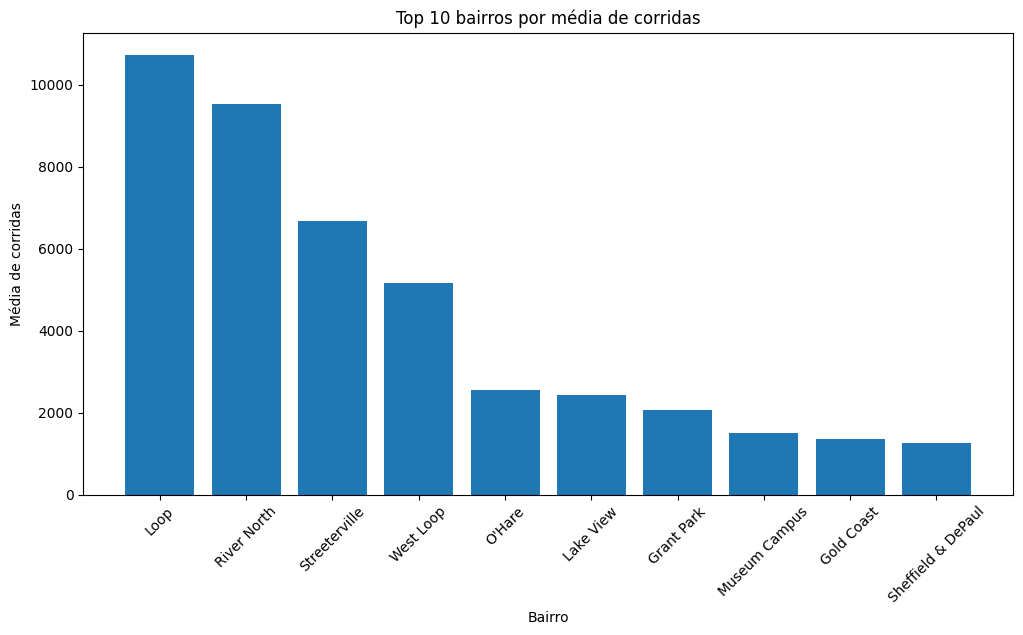

In [9]:
plt.figure(figsize=(12,6))

plt.bar(
    top_10_neighborhoods['dropoff_location_name'],
    top_10_neighborhoods['average_trips']
)

plt.title('Top 10 bairros por média de corridas')
plt.xlabel('Bairro')
plt.ylabel('Média de corridas')
plt.xticks(rotation=45)

plt.show()

# Neighborhood chart conclusion

It can be observed that some neighborhoods concentrate a significantly higher volume of rides compared to the others.

This difference suggests the existence of regions with greater economic, commercial, or tourist activity, making them frequent destinations for transportation service users.

The results indicate that ride demand is not evenly distributed across the city, but rather concentrated in specific areas.

# Taxi company analysis

In this step, the number of rides performed by each taxi company is analyzed.

The goal is to identify which companies had the largest market share during the analyzed period.

In [10]:
company_df.sort_values(
    by='trips_amount',
    ascending=False
).head()

,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasing,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299


# Taxi company visualization

The chart below shows the number of rides recorded per taxi company.

Since there is a large number of companies, the visualization makes it easy to quickly identify which organizations account for the largest share of completed rides.

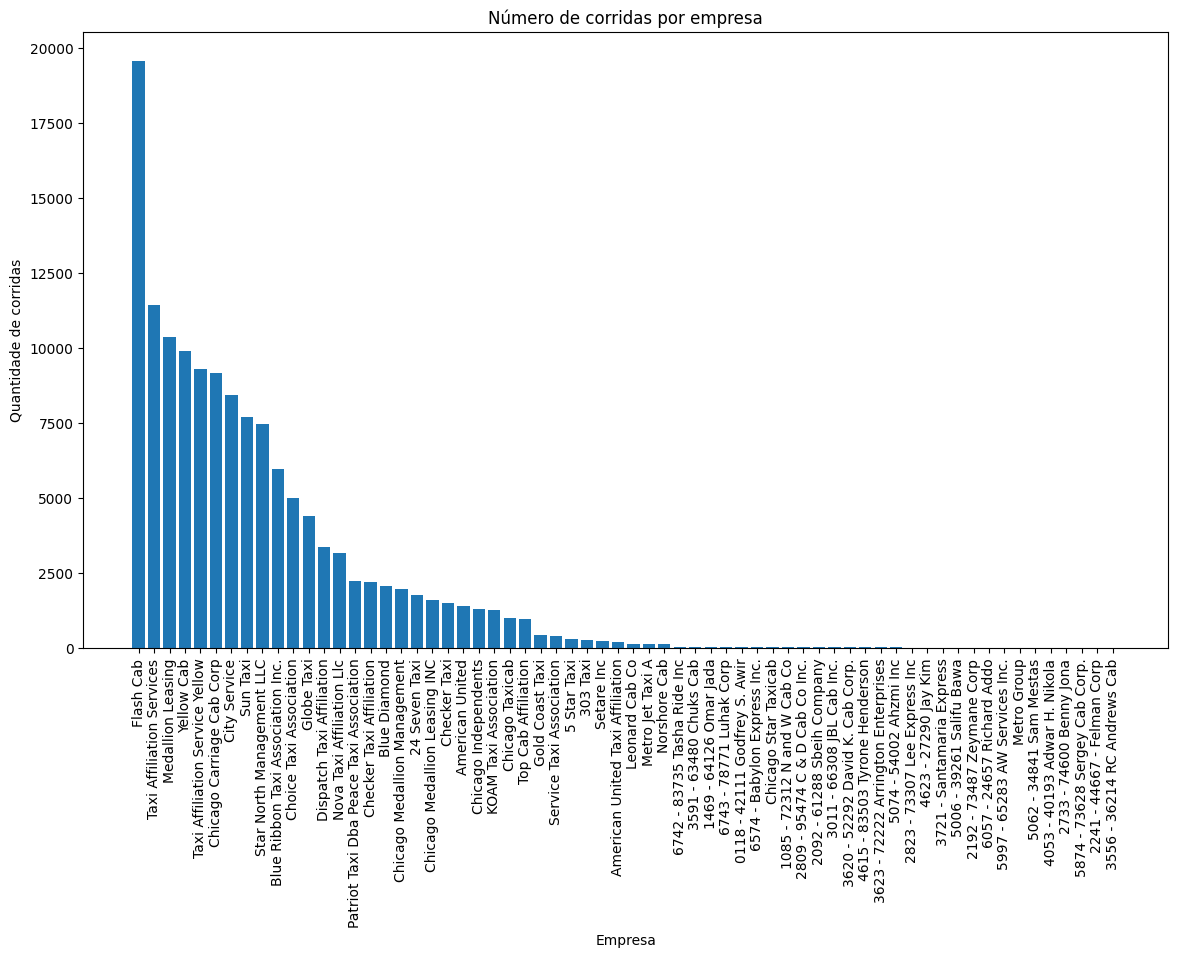

In [11]:
company_sorted = company_df.sort_values(
    by='trips_amount',
    ascending=False
)

plt.figure(figsize=(14,8))

plt.bar(
    company_sorted['company_name'],
    company_sorted['trips_amount']
)

plt.title('Número de corridas por empresa')
plt.xlabel('Empresa')
plt.ylabel('Quantidade de corridas')

plt.xticks(rotation=90)

plt.show()

In [12]:
top_10_companies = company_df.sort_values(
    by='trips_amount',
    ascending=False
).head(10)

print(top_10_companies)

                        company_name  trips_amount
0                          Flash Cab         19558
1          Taxi Affiliation Services         11422
2                  Medallion Leasing         10367
3                         Yellow Cab          9888
4    Taxi Affiliation Service Yellow          9299
5          Chicago Carriage Cab Corp          9181
6                       City Service          8448
7                           Sun Taxi          7701
8          Star North Management LLC          7455
9  Blue Ribbon Taxi Association Inc.          5953


# Visualization of the top 10 taxi companies

After identifying the companies with the highest number of rides, a graphical visualization is built to make comparison easier.

The chart shows which companies concentrate the largest share of the transportation market during the analyzed period.

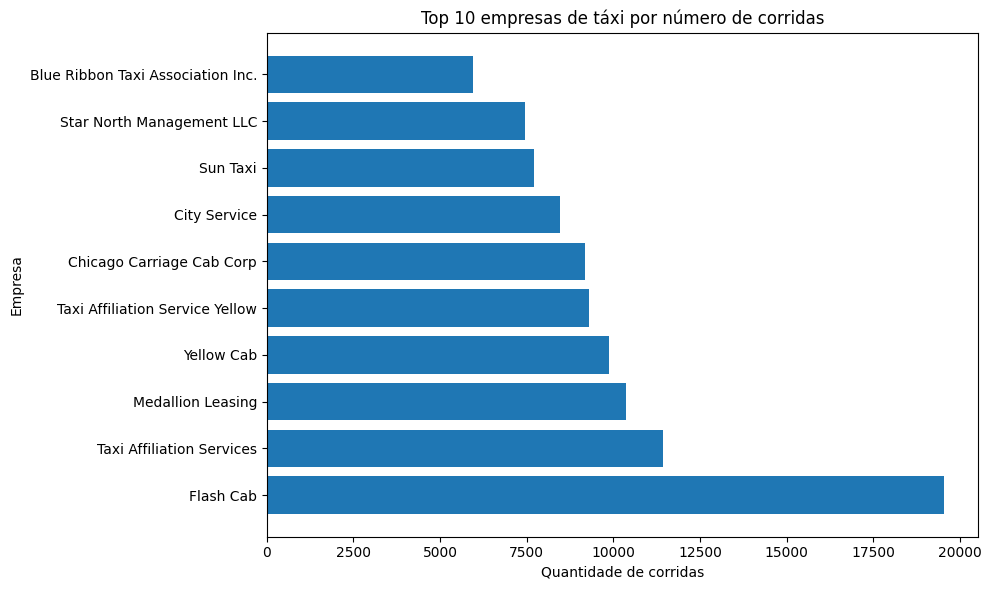

In [13]:
plt.figure(figsize=(10,6))

plt.barh(
    top_10_companies['company_name'],
    top_10_companies['trips_amount']
)

plt.title('Top 10 empresas de táxi por número de corridas')
plt.xlabel('Quantidade de corridas')
plt.ylabel('Empresa')

plt.tight_layout()

plt.show()

# Taxi company chart conclusion

The chart shows a significant difference between the companies with the highest number of rides and the rest of the market participants.

It can be observed that some companies concentrate a large share of demand, indicating possible market leadership during the analyzed period.

This concentration may be related to factors such as fleet size, vehicle availability, brand recognition, or the scope of operations across the city.

# Visualization of the top 10 destination neighborhoods

After identifying the neighborhoods with the highest average number of completed rides, a graphical visualization is built to make comparison easier.

The goal is to identify which regions concentrate the highest demand as trip destinations in Chicago.

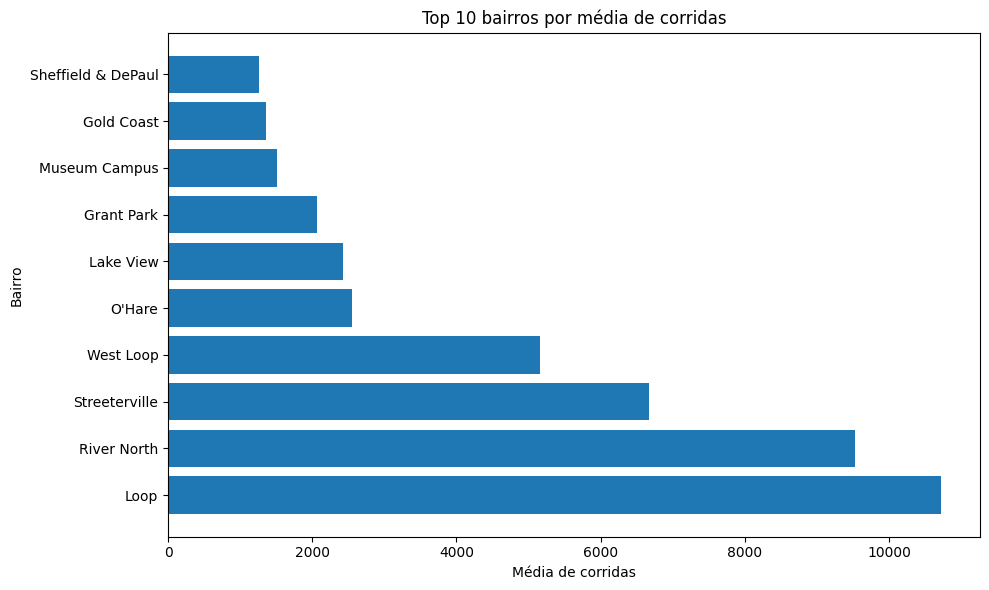

In [14]:
plt.figure(figsize=(10,6))

plt.barh(
    top_10_neighborhoods['dropoff_location_name'],
    top_10_neighborhoods['average_trips']
)

plt.title('Top 10 bairros por média de corridas')
plt.xlabel('Média de corridas')
plt.ylabel('Bairro')

plt.tight_layout()

plt.show()

# Neighborhood chart conclusion

The chart shows that some neighborhoods receive a significantly higher volume of rides compared to others.

This concentration suggests that certain regions have a higher passenger flow and act as important centers of economic, commercial, or tourist activity.

The results show that transportation demand is not evenly distributed across the city, but rather concentrated in specific areas of Chicago.

# Preparing the data for the hypothesis test

In this step, the data related to rides between the Loop neighborhood and O'Hare International Airport is prepared.

Before performing the statistical test, the dataset's structure, data types, and data quality are checked.

The date/time column is also converted to datetime format, enabling further time-based analysis if needed.

In [15]:
rides_df.head()

,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410.0
1,2017-11-25 14:00:00,Good,1920.0
2,2017-11-25 12:00:00,Good,1543.0
3,2017-11-04 10:00:00,Good,2512.0
4,2017-11-11 07:00:00,Good,1440.0


In [16]:
rides_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB


In [17]:
print(rides_df.isna().sum())
print()
print(rides_df.duplicated().sum())

start_ts              0
weather_conditions    0
duration_seconds      0
dtype: int64

197


In [18]:
rides_df['start_ts'] = pd.to_datetime(rides_df['start_ts'])

# Data quality assessment for the hypothesis test

The analysis showed that the dataset has no missing values, indicating that all observations contain the information needed for the statistical test.

Duplicate records were identified. Since each row represents a ride and the dataset has no unique identifier for each trip, it isn't possible to tell whether these are genuinely repeated rides or collection artifacts.

To avoid overcounting, the duplicate records were removed from the dataset (`drop_duplicates()`), leaving 871 unique rides for the analysis.

The `start_ts` column was also converted to datetime format, ensuring the variable is ready for any future time-based analysis.

In [19]:
rides_df = rides_df.drop_duplicates()

# Defining the research problem

In this step, we investigate whether weather conditions influence the duration of rides between the Loop neighborhood and O'Hare International Airport on Saturdays.

To answer this question, a statistical test is performed comparing ride duration under favorable weather conditions and rainy conditions.

Before applying the test, the statistical hypotheses that will guide the analysis are defined.



# Hypothesis formulation

The goal of this step is to verify whether weather conditions influence the average ride duration between the Loop neighborhood and O'Hare International Airport on Saturdays.

To do this, the duration of rides performed in rainy conditions is compared with those performed in favorable weather conditions.

The hypotheses defined for the test are:

**Null hypothesis (H₀):**
The average ride duration on rainy Saturdays is equal to the average ride duration on non-rainy Saturdays.

**Alternative hypothesis (H₁):**
The average ride duration on rainy Saturdays is different from the average ride duration on non-rainy Saturdays.

A significance level (α) of **5% (0.05)** is adopted, a value widely used in statistical tests to control the probability of a Type I error.



# Choosing the statistical test

To evaluate the proposed hypothesis, a statistical test comparing two independent samples is used.

This method was chosen because the goal is to check whether there is a statistically significant difference in average ride duration between two distinct groups: rides performed in rainy conditions and rides performed in favorable weather conditions.

This test is appropriate because the analyzed variable is numerical (ride duration in seconds) and the compared groups are independent of each other.

In [21]:
rainy_rides = rides_df[rides_df['weather_conditions'] == 'Bad']['duration_seconds']

good_weather_rides = rides_df[rides_df['weather_conditions'] == 'Good']['duration_seconds']

In [22]:
print('Corridas com clima ruim:', len(rainy_rides))
print('Corridas com clima bom:', len(good_weather_rides))

Corridas com clima ruim: 148
Corridas com clima bom: 723


In [23]:
from scipy.stats import ttest_ind

results = ttest_ind(rainy_rides, good_weather_rides, equal_var=False)

print('Valor-p:', results.pvalue)

Valor-p: 9.126383933880083e-08


# Interpreting the results

The obtained p-value was approximately 9.13 x 10^-8, far below the adopted significance level (alpha = 0.05).

Since the p-value is smaller than alpha, we reject the null hypothesis (H0).

This indicates there is sufficient statistical evidence to conclude that the average ride duration between the Loop and O'Hare International Airport on Saturdays differs between bad weather and good weather conditions.

# Conclusion

Based on the statistical test performed, we reject the null hypothesis (H0), since the obtained p-value was below the significance level of 0.05.

The results provide statistical evidence that the average ride duration between the Loop and O'Hare International Airport on Saturdays differs between bad weather and good weather conditions.

Therefore, the hypothesis that average ride duration changes on rainy Saturdays is supported by the analyzed data.